<a href="https://colab.research.google.com/github/nmhom/MAT-422/blob/main/MAT422_HW_3.3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW 3.3 - Unconstrained Optimization

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import matplotlib.patches as patches

## 3.3.1. Necessary and sufficient conditions of local minimizers

### Definition 3.3.1: Global Minimizer
A point $x^* \in \mathbb{R}^d$ is a global minimizer of $f$ if $f(x) \geq f(x^*), \qquad \forall x \in \mathbb{R}^d$

A global minimizer is a point where the function has its lowest value over the entire domain.

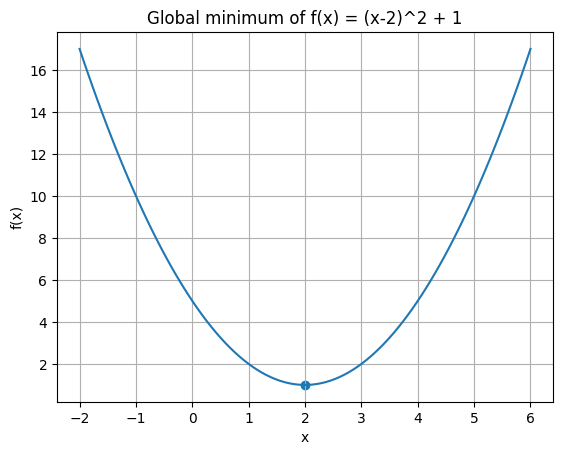

Global minimizer: 2
Minimum value: 1


In [20]:
# For example, f(x) = (x-2)^2 + 1
def f_glob_min(x):
  return ((x - 2)**2 + 1)

x = np.linspace(-2, 6, 100)
y = f_glob_min(x)

plt.plot(x,y)
plt.scatter(2, f_glob_min(2))
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Global minimum of f(x) = (x-2)^2 + 1")
plt.grid()
plt.show()

print("Global minimizer:", 2)
print("Minimum value:", f_glob_min(2))

### Definition 3.3.2: Local Minimizer

A point $x^*$ is a local minimizer if there exists some $\delta > 0$ such that $$ f(x) \geq f(x^*), \qquad \forall x \in B_\delta(x^*) \setminus \{x^*\}.$$ If the inequality is strict, $x^*$ is a strict local minimizer.

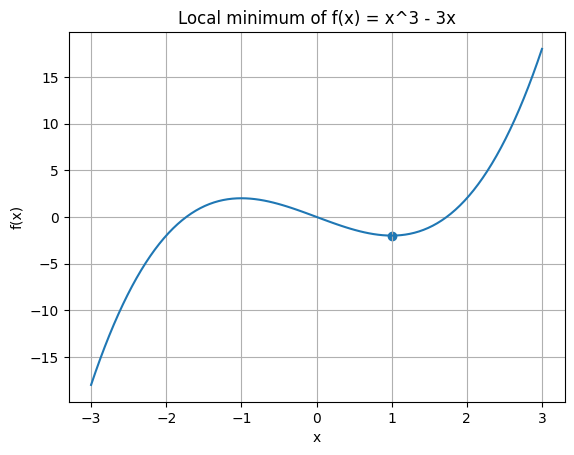

Local minimizer: 1
Function value: -2


In [21]:
# A local minimizer is the lowest point within a small neighborhood around x*
# even if there might be a lower point somewhere else
def f_local_min(x):
  return x**3 - 3*x

x = np.linspace(-3, 3, 100)
y = f_local_min(x)

plt.plot(x,y)
plt.scatter(1, f_local_min(1))
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Local minimum of f(x) = x^3 - 3x")
plt.grid()
plt.show()

print("Local minimizer:", 1)
print("Function value:", f_local_min(1))

### Theorem 3.3.6 (First-order necessary condition)
Let f be continuously differentiable. If $x^*$ is a local minimizer, then $$\nabla f(x^*) = 0$$ In other words, at a differentiable local minimum, there cannot be a direction in which the function immediately decreases. Therefore, the gradient must be zero.

Consider the function $$f(x)=x^3 - 3x$$ The first-order necessary condition states that if $x^*$ is a differentiable local minimizer, then $$f'(x^*) = 0$$

We can calculate the derivative and find the stationary points where the derivative is 0.

In [22]:
# f(x) = x^3 - 3x

# Define the function
x = sp.symbols('x')
f = x**3 - 3*x

# Calculate the derivative
f_prime = sp.diff(f,x)

print("f(x) =", f)
print("f'(x) =", f_prime)

# Find the stationary points where f'(x) = 0
stat_points = sp.solve(f_prime, x)
print("Stationary points:", stat_points)

# Check the first-order necessary condition at x* = 1
x_star = 1
deriv_at_x_star = f_prime.subs(x, x_star)
print("f'(x*) =", deriv_at_x_star)

f(x) = x**3 - 3*x
f'(x) = 3*x**2 - 3
Stationary points: [-1, 1]
f'(x*) = 0


### Definition 3.3.7 (Positive semidefinite matrix)
A symmetric matrix H is positive semidefinite (PSD) if $$v^THv \geq 0, \qquad \forall v \in \mathbb{R}^d.$$

**Theorem 3.3.8** (Second-order necessary condition)
If $x^*$ is a local minimizer and $f$ is twice continuously differentiable, then $$\nabla^2f(x^*) \succeq 0$$

In other words, the Hessian at a local minimum must be positive semidefinite.

In [23]:
# f(x,y) = x^2 + y^2

x,y = sp.symbols('x y')
f = x**2 + y**2

# Calculate the Hessian matrix
hessian = sp.hessian(f, (x,y))
print("Hessian matrix:")
sp.pprint(hessian)

# Evaluate the Hessian at the local minimizer (0,0)
x_star = {x:0,y:0}
hessian_at_min = hessian.subs({x: 0, y: 0})

print("Hessian at local minimizer (0,0):")
sp.pprint(hessian_at_min)

# Calculate the eighenvalues of the Hessian
eigenvalues = hessian.eigenvals()

print("Eigenvalues of the Hessian:")
print(eigenvalues)

Hessian matrix:
⎡2  0⎤
⎢    ⎥
⎣0  2⎦
Hessian at local minimizer (0,0):
⎡2  0⎤
⎢    ⎥
⎣0  2⎦
Eigenvalues of the Hessian:
{2: 2}


### Theorem 3.3.10 (Second-order sufficient condition)
If $$\nabla f(x^*)=0$$ and $$\nabla^2f(x^*) \succ 0$$ then $x^*$ is a strict local minimizer.

In [24]:
# f(x,y) = x^2 + 2y^2
x,y = sp.symbols('x y')
f = x**2 + 2*y**2

# Step 1: Find the gradient
gradient = sp.derive_by_array(f, (x,y))

print("Gradient:")
sp.pprint(gradient)

# Set the gradient equal to zero
stationary_point = sp.solve(gradient, (x,y))

print("Stationary point:")
print(stationary_point)

# Step 2: Find the Hessian
hessian = sp.hessian(f, (x,y))
print("Hessian matrix:")
sp.pprint(hessian)

# Evaluate the Hessian at the stationary point
hessian_at_min = hessian.subs(stationary_point)

print("Hessian at stationary point:")
sp.pprint(hessian_at_min)

# Step 3: Calculate the eighenvalues
eigenvalues = hessian_at_min.eigenvals()

print("Eigenvalues of the Hessian:")
print(eigenvalues)

Gradient:
[2⋅x  4⋅y]
Stationary point:
{x: 0, y: 0}
Hessian matrix:
⎡2  0⎤
⎢    ⎥
⎣0  4⎦
Hessian at stationary point:
⎡2  0⎤
⎢    ⎥
⎣0  4⎦
Eigenvalues of the Hessian:
{2: 1, 4: 1}


The gradient is zero at the stationary point (0,0). The Hessian has eigenvalues 2 and 4, which are both positive. Therefore, the Hessian is positive definite. By the second-order sufficient condition, (0,0) is a strict local minimizer.

## 3.3.2. Convexity and global minimizers
Convexity provides global structure for an optimization problem. Unlike local optimality conditions, which only describe the behavior near a point, convexity allows us to make conclusions about the function over its entire domain.

### Definition 3.3.11: Convex Set

A set $D \subseteq \mathbb{R}^d$ is convex if

$$
(1-\alpha)x + \alpha y \in D,
\qquad
\forall x,y \in D,\quad \alpha \in [0,1].
$$

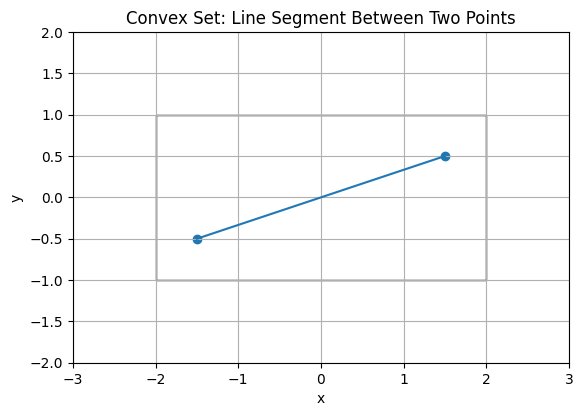

In [25]:
# Create a blank figure and a set of axes to draw on
fig, ax = plt.subplots()

# Makes a rectangle whose bottom left corner is at (-2,-1), with width 4 and height 2
rectangle = patches.Rectangle((-2,-1), 4,2, fill=False)
ax.add_patch(rectangle)

# Plot two points inside the rectangle
x = np.array([-1.5, -0.5])
y = np.array([1.5, 0.5])

# Plots the two points as dots. scatter wants all the x-coordinates in one list and all y-coordinates in another
ax.scatter([x[0], y[0]], [x[1], y[1]])

# Creates 100 evenly spaced values of alpha from 0 to 1
alpha = np.linspace(0,1,100)

# Computes (1-alpha)x + alphay for all 100 values of a at once
line = (1 - alpha[:,None]) * x + alpha[:,None] * y

# Draws the segment
ax.plot(line[:, 0], line[:,1])

ax.set_xlim(-3, 3)
ax.set_ylim(-2, 2)
ax.set_aspect('equal')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Convex Set: Line Segment Between Two Points")
plt.grid()
plt.show()

The whole segment stays inside the rectange. A rectangle is convex, so this happens for any two points you pick.

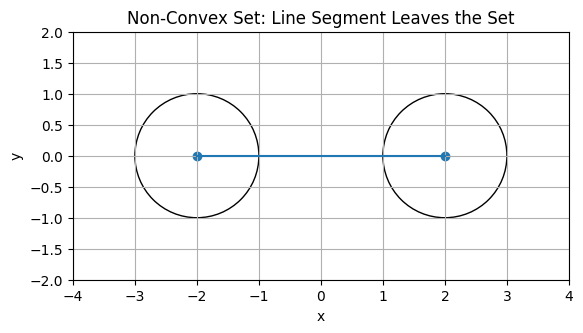

In [26]:
fig, ax = plt.subplots()
# Drafts two circules of radius 1, one centered at (-2,0) and one at (2,0)
circle1 = patches.Circle((-2,0), 1, fill=False)
circle2 = patches.Circle((2,0), 1, fill=False)
ax.add_patch(circle1)
ax.add_patch(circle2)

# Choose one point from each circle
x = np.array([-2, 0])
y = np.array([2, 0])

# Plots the two points as dots. scatter wants all the x-coordinates in one list and all y-coordinates in another
ax.scatter([x[0], y[0]], [x[1], y[1]])

# Creates 100 evenly spaced values of alpha from 0 to 1
alpha = np.linspace(0,1,100)

# Computes (1-alpha)x + alphay for all 100 values of a at once
line = (1 - alpha[:,None]) * x + alpha[:,None] * y

# Draws the segment
ax.plot(line[:, 0], line[:,1])

ax.set_xlim(-4, 4)
ax.set_ylim(-2, 2)
ax.set_aspect('equal')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Non-Convex Set: Line Segment Leaves the Set")
plt.grid()
plt.show()

A set is convex if the line segment connecting any two points in the set remains entirely within the set. The rectangle demonstrates a convex set because the segment between the selected points stays inside the rectangle. The two-circle example is not convex because a segment connecting points from the two circles contains points outside the set.

### Definition 3.3.13: Convex Function

A function $f:\mathbb{R}^d \rightarrow \mathbb{R}$ is convex if

$$
f((1-\alpha)x + \alpha y)
\leq
(1-\alpha)f(x) + \alpha f(y),
$$

for all $x,y$ and $\alpha \in [0,1]$.

A function is convex when the line segment connecting two points on its graph lies above or on the graph.

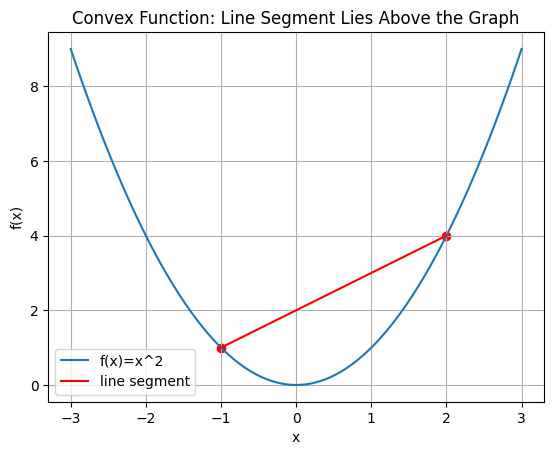

In [27]:
fig, ax = plt.subplots()

# The function f(x) = x^2
def f(x):
  return x**2

# Plot the curve
x_vals = np.linspace(-3,3,100)
ax.plot(x_vals, f(x_vals), label="f(x)=x^2")

# Choose two points on the x-axis
x_1 = -1
x_2 = 2

# Plot the two points on the graph
ax.scatter([x_1, x_2], [f(x_1), f(x_2)], color="red")

# Points along the segment, using the definition
alpha = np.linspace(0, 1, 100)
seg_x = (1 - alpha) * x_1 + alpha * x_2
seg_y = (1 - alpha) * f(x_1) + alpha * f(x_2)

# Plot the line segment
ax.plot(seg_x, seg_y, color="red", label="line segment")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Convex Function: Line Segment Lies Above the Graph")
plt.legend()
plt.grid()
plt.show()

### Lemma 3.3.16: Second-Order Convexity Condition

Let $f$ be twice continuously differentiable. Then $f$ is convex if and only if its Hessian is positive semidefinite for every $x$.

$$
f \text{ is convex}
\iff
\nabla^2 f(x) \succeq 0,
\qquad \forall x.
$$

The Hessian describes the curvature of a function. If the Hessian is positive semidefinite everywhere, the function is convex.

In [28]:
x, y = sp.symbols('x y')

# Convex ex: f(x,y) = x^2 + xy + y^2
f_conv = x**2 + x*y + y**2

hessian_conv = sp.hessian(f_conv, (x,y))
print("Convex function: ", f_conv)
print("Hessian matrix:")
sp.pprint(hessian_conv)
print("Eigenvalues:", hessian_conv.eigenvals())

# Non-convex ex: f(x,y) = x^2 - y^2
f_non = x**2 - y**2
hessian_non_conv = sp.hessian(f_non, (x,y))
print("Non-Convex function: ", f_non)
print("Hessian matrix:")
sp.pprint(hessian_non_conv)
print("Eigenvalues:", hessian_non_conv.eigenvals())

Convex function:  x**2 + x*y + y**2
Hessian matrix:
⎡2  1⎤
⎢    ⎥
⎣1  2⎦
Eigenvalues: {3: 1, 1: 1}
Non-Convex function:  x**2 - y**2
Hessian matrix:
⎡2  0 ⎤
⎢     ⎥
⎣0  -2⎦
Eigenvalues: {2: 1, -2: 1}


Since the Hessian of equation 1 is constant with eigenvalues 1 and 3, it is positive semidefinite for every (x,y), so equation 1 is convex by Lemma 3.3.16. The Hessian of equation 2 has negative eigenvalue, so it is not positive semidefinite and equation 2 is not convex.

### Theorem 3.3.18: Stationary Point of a Convex Function
If $f$ is continuously differentiable and convex, and $$\nabla f(x^*) = 0,$$ then $x^*$ is a global minimizer.

In [29]:
# f(x) = x^2 + xy + y^2, find where the gradiant is 0, then check that no other point gives a smaller value
x, y = sp.symbols('x y')
f = x**2 + x*y + y**2

# Calculate the gradient
gradient = sp.derive_by_array(f, (x,y))

print("Gradient:")
sp.pprint(gradient)

# Set the gradient equal to zero
stationary_point = sp.solve(gradient, (x,y))

print("Stationary point:")
min_value = f.subs(stationary_point)
print(stationary_point)
print("Minimum value:", min_value)

Gradient:
[2⋅x + y  x + 2⋅y]
Stationary point:
{x: 0, y: 0}
Minimum value: 0


### Theorem 3.3.19: Global Minimizers of Convex Functions
If $f$ is convex, then every local minimizer of $f$ is also a global minimizer.

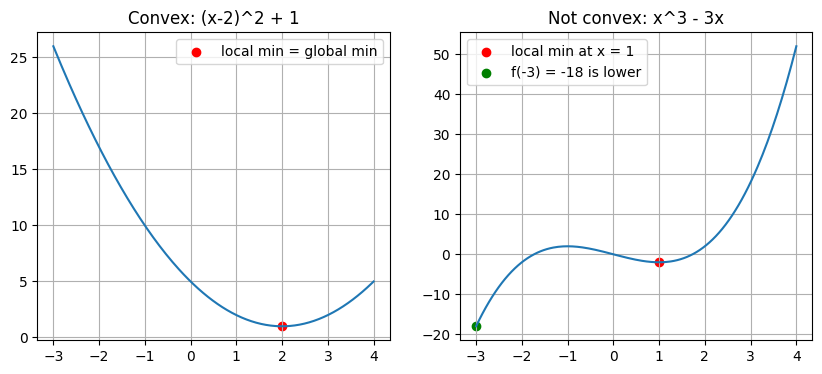

In [30]:
x_vals = np.linspace(-3, 4, 200)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Convex: local minimum = global minimum
axes[0].plot(x_vals, (x_vals - 2)**2 + 1)
axes[0].scatter(2, 1, color="red", label="local min = global min")
axes[0].set_title("Convex: (x-2)^2 + 1")
axes[0].legend()
axes[0].grid()

# Not convex: local minimum is NOT global
axes[1].plot(x_vals, x_vals**3 - 3*x_vals)
axes[1].scatter(1, -2, color="red", label="local min at x = 1")
axes[1].scatter(-3, -18, color="green", label="f(-3) = -18 is lower")
axes[1].set_title("Not convex: x^3 - 3x")
axes[1].legend()
axes[1].grid()

plt.show()

## 3.3.3. Gradient descent

Gradient descent is an iterative optimization algorithm that finds a minimum by repeatedly moving in the direction opposite the gradient. Since the gradient points in the direction of greatest increase, its negative points in the direction of greatest decrease.
$$
\min_{x\in\mathbb{R}^d} f(x)
$$



### Lemma 3.3.22: Steepest Descent

For a continuously differentiable function, the direction of steepest descent at $x_0$ is

$$
v^* =
-\frac{\nabla f(x_0)}
{\|\nabla f(x_0)\|}.
$$

This means that the negative gradient points in the direction of greatest decrease of the function.

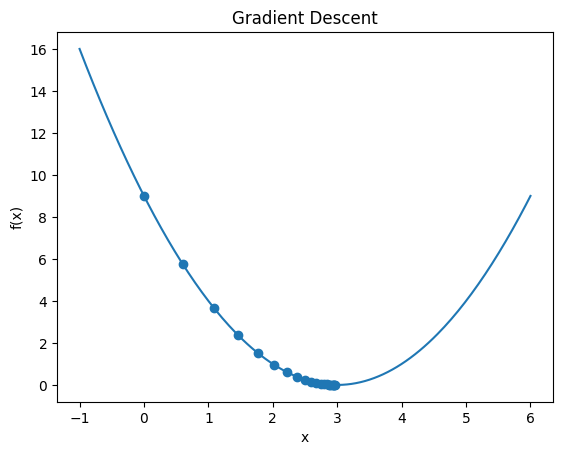

In [31]:
# f(x) = (x - 3)^2
def f(x):
  return (x-3)**2

# Compute the gradient
def grad_f(x):
  return 2 * (x - 3)

# Starting point
x = 0
alpha = 0.1

# Store points visited
points = [x]

# Gradient descent
for _ in range(20):
  x = x - alpha * grad_f(x)
  points.append(x)

# Plot the function
x_values = np.linspace(-1, 6, 200)
plt.plot(x_values, f(x_values))

# Plot gradient descent steps
plt.scatter(points, [f(x) for x in points])

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Gradient Descent")
plt.show()


This example applies gradient descent to $f(x)=(x-3)^2$, which has a minimum at $x=3.$ Starting from $x=0$, the algorithm repeatedly updates $x$ using the negative gradient. The plotted points show how the algorithm moves toward the minimum over the iterations.

### Gradient Descent Update Rule

Gradient descent repeatedly updates the current point using

$$
x_{k+1}
=
x_k-\alpha_k\nabla f(x_k),
$$

where $\alpha_k > 0$ is the step size.

The negative gradient determines the direction of movement, while the step size determines how far the algorithm moves in that direction.

Gradient: [6. 4.]
Steepest descent direction: [-0.83205029 -0.5547002 ]


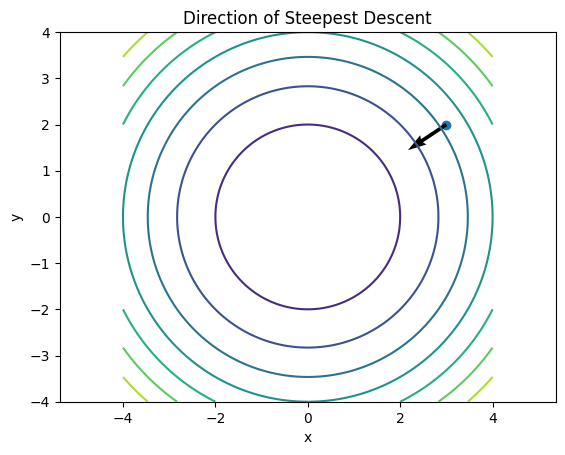

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Function
def f(x, y):
    return x**2 + y**2

# Gradient
def gradient(x, y):
    return np.array([2*x, 2*y])

# Starting point
x0 = np.array([3.0, 2.0])

# Compute gradient
grad = gradient(x0[0], x0[1])

# Steepest descent direction
direction = -grad / np.linalg.norm(grad)

print("Gradient:", grad)
print("Steepest descent direction:", direction)

# Plot
x = np.linspace(-4, 4, 100)
y = np.linspace(-4, 4, 100)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

plt.contour(X, Y, Z)

# Starting point
plt.scatter(x0[0], x0[1])

# Steepest descent direction
plt.quiver(
    x0[0], x0[1],
    direction[0], direction[1],
    angles="xy",
    scale_units="xy",
    scale=1
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Direction of Steepest Descent")
plt.axis("equal")
plt.show()

Here, $x_k$ is the current point, $\nabla f(x_k)$ is the gradient at that point, and $\alpha_k$ is the step size. The algorithm continues updating $x_k$ until it reaches a point where the gradient is close to zero, indicating that it is near a stationary point.


### Theorem 3.3.23: Gradient Descent with Line Search

At each iteration, the step size can be chosen by minimizing the function along the direction of steepest descent:

$$
\alpha_k =
\arg\min_{\alpha>0}
f\left(x_k-\alpha\nabla f(x_k)\right).
$$

With this choice of step size,

$$
f(x_{k+1})\leq f(x_k).
$$

Therefore, the function value does not increase from one iteration to the next.


Best step size: 0.5


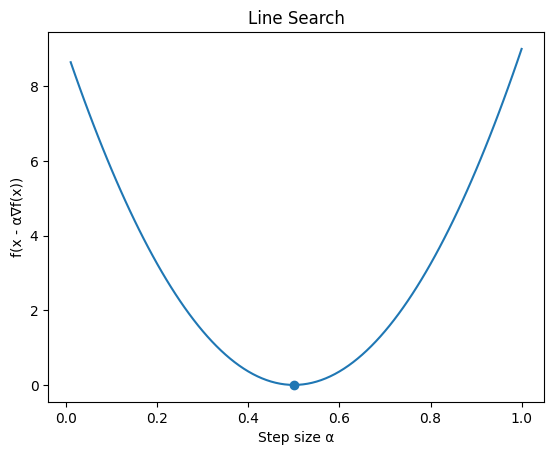

In [34]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return (x - 3)**2

def grad_f(x):
    return 2 * (x - 3)

# Starting point
x = 0

# Possible step sizes
alphas = np.linspace(0.01, 1, 100)

# Evaluate each possible step
values = []

for alpha in alphas:
    x_new = x - alpha * grad_f(x)
    values.append(f(x_new))

# Find the step size that gives the smallest value
best_alpha = alphas[np.argmin(values)]

print("Best step size:", best_alpha)

# Plot function value for each step size
plt.plot(alphas, values)
plt.scatter(best_alpha, min(values))

plt.xlabel("Step size α")
plt.ylabel("f(x - α∇f(x))")
plt.title("Line Search")
plt.show()

This example demonstrates line search by testing different step sizes and evaluating the resulting function values. The step size that produces the smallest function value is selected as the best step size. The plot shows how the function value changes as the step size varies.